# L5. Teaching It to See

The device learns something new by writing example vectors to memory: no retraining, no fine-tuning. Pick a subject, give it a name, and teach it yourself. Then everything you built lands in one assistant that answers questions about your day and recognizes what you taught it, offline.

## 1. The subject you'll teach

In [1]:
from helper import object_photos

MY_LABEL = "rubber duck"      # the name it learns
TEACH_PHOTOS = []             # 2+ links or filenames, empty = example
TEST_PHOTO = ""               # one more, to test with

# What it should remember about your subject, and how you'll ask for it.
MY_NOTE = "Rubber duck for the bath, from the toy shop on Elm Street"
MY_QUESTION = "what did I get at the toy shop?"

teach_photos, test_photo = object_photos(TEACH_PHOTOS, TEST_PHOTO)

2 teach photos + 1 test photo ready (bundled example: rubber duck)


## 2. An object-memory shard

In [2]:
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
    Point, UpdateOperation, Query, QueryRequest,
)
from helper import embed_image, fresh_start

OBJECT_DIR = fresh_start("./object_shard")

config = EdgeConfig(
    vectors={
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
object_shard = EdgeShard.create(OBJECT_DIR, config)
RECOGNIZE_THRESHOLD = 0.80
print("Object shard ready. threshold =", RECOGNIZE_THRESHOLD)

Object shard ready. threshold = 0.8


## 3. Give it a few memories first

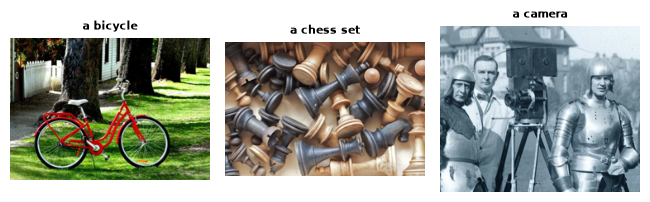

In [3]:
from helper import show_images


def teach(shard, object_id, label, view_paths, start_id):
    vectors = embed_image(view_paths)
    points = [
        Point(
            id=start_id + i,
            vector={"image": vectors[i]},
            payload={"object_id": object_id, "label": label,
                     "view_id": i, "file": view_paths[i]},
        )
        for i in range(len(view_paths))
    ]
    shard.update(UpdateOperation.upsert_points(points))
    shard.optimize()
    # flush to disk now: a taught memory should survive a power cut
    shard.flush()


SEEDS = [("bicycle", "a bicycle"),
         ("chess_set", "a chess set"),
         ("camera", "a camera")]
for i, (name, label) in enumerate(SEEDS):
    teach(object_shard, name, label,
          [f"./ro_shared_data/bank/{name}.jpg"], start_id=i)

show_images([f"./ro_shared_data/bank/{name}.jpg" for name, _ in SEEDS],
            captions=[label for _, label in SEEDS])

## 4. Show it your subject: not recognized yet

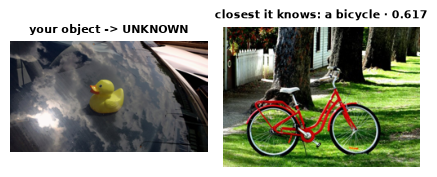

In [4]:
def recognize(shard, query_path):
    query_vector = embed_image([query_path])[0]
    hits = shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="image"),
            limit=1,
            with_payload=True,
        )
    )
    top = hits[0]
    return top, top.score >= RECOGNIZE_THRESHOLD


top, known = recognize(object_shard, test_photo)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([test_photo, top.payload["file"]],
            captions=[f"your object -> {verdict}",
                      f"closest it knows: {top.payload['label']}"
                      f" · {top.score:.3f}"])

## 5. Teach it, recognize it

In [5]:
teach(object_shard, "my_subject", MY_LABEL, teach_photos, start_id=100)
print(f'Taught "{MY_LABEL}" from {len(teach_photos)} photo(s).',
      object_shard.info().points_count, "photos in memory")

Taught "rubber duck" from 2 photo(s). 5 photos in memory


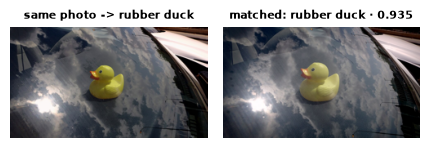

In [6]:
top, known = recognize(object_shard, test_photo)
verdict = top.payload["label"] if known else "UNKNOWN"
matched = f"matched: {top.payload['label']} · {top.score:.3f}"
show_images([test_photo, top.payload["file"]],
            captions=[f"same photo -> {verdict}", matched])

## 6. Inspect the threshold gap

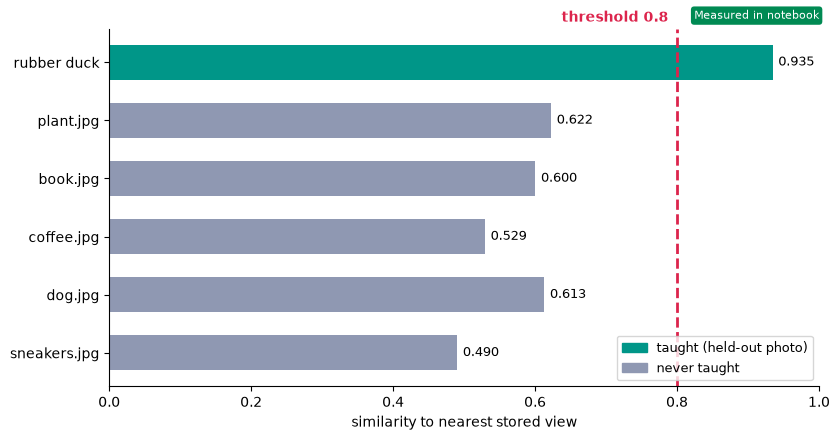

In [7]:
from helper import score_gap_chart

top, _ = recognize(object_shard, test_photo)
taught = [(MY_LABEL, top.score)]

foreign = []
for name in ["plant.jpg", "book.jpg", "coffee.jpg",
             "dog.jpg", "sneakers.jpg"]:
    t, _ = recognize(object_shard, f"./ro_shared_data/images/{name}")
    foreign.append((name, t.score))

score_gap_chart(taught, foreign, RECOGNIZE_THRESHOLD)

## 7. Assemble the assistant

In [8]:
import json
from helper import embed_text, receipt_table

ASSISTANT_DIR = fresh_start("./assistant_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
assistant_shard = EdgeShard.create(ASSISTANT_DIR, config)

day = json.load(open("./ro_shared_data/memories.json"))
history = json.load(open("./ro_shared_data/recent_days.json"))
notes = [m for m in day + history
         if m["source_type"] in ("text", "voice")]
photos = [m for m in day if m["source_type"] == "photo"]

note_texts = [m.get("note") or m["transcript"] for m in notes]
text_vectors = embed_text(note_texts)
assistant_shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": vector}, payload=m)
    for m, vector in zip(notes, text_vectors)
]))
photo_paths = [f"./ro_shared_data/images/{m['file']}" for m in photos]
image_vectors = embed_image(photo_paths)
assistant_shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": vector}, payload=m)
    for m, vector in zip(photos, image_vectors)
]))
print("Stored", assistant_shard.info().points_count,
      "recorded memories")

Stored 144 recorded memories


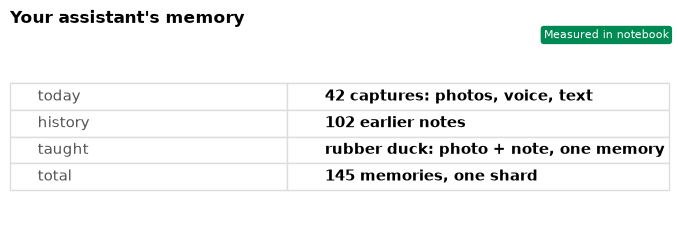

In [9]:
# One memory, two ways in: the photo's vector and the note's, one point.
my_memory = Point(
    id=5000,
    vector={"image": embed_image([teach_photos[0]])[0],
            "text": embed_text([MY_NOTE])[0]},
    payload={"object_id": "my_subject", "label": MY_LABEL,
             "file": teach_photos[0], "note": MY_NOTE},
)
assistant_shard.update(UpdateOperation.upsert_points([my_memory]))
assistant_shard.optimize()
assistant_shard.flush()

total = assistant_shard.info().points_count

receipt_table([
    ("today", f"{len(day)} captures: photos, voice, text"),
    ("history", f"{len(history)} earlier notes"),
    ("taught", f"{MY_LABEL}: photo + note, one memory"),
    ("total", f"{total} memories, one shard"),
], title="Your assistant's memory")

## 8. Ask it, then show it


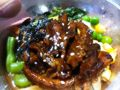

In [10]:
from helper import embed_query, embed_query_clip, memory_inbox


def recall(shard, question):
    text_vector = embed_query(question)
    image_vector = embed_query_clip(question)
    # fetch extra text hits so one lane cannot crowd out the other
    text_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(text_vector, using="text"),
            limit=10,
            with_payload=True,
        )
    )
    image_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(image_vector, using="image"),
            limit=3,
            with_payload=True,
        )
    )
    return {
        "Photos": [h for h in image_hits
                   if h.payload.get("source_type") == "photo"][:1],
        "Voice Notes": [h for h in text_hits
                        if h.payload.get("source_type") == "voice"][:3],
        "Text Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "text"][:3],
    }


hits = recall(assistant_shard, "the ramen place downtown")
memory_inbox(hits, "./ro_shared_data/images", min_score=0.6)

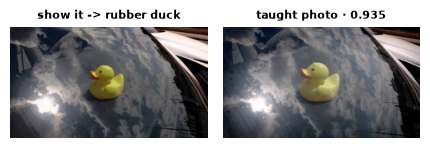

I remember this: Rubber duck for the bath, from the toy shop on Elm Street
Asked by words  -> memory 5000: Rubber duck for the bath, from the toy shop on Elm Street
Shown the photo -> memory 5000: rubber duck, score 0.935


In [11]:
top, known = recognize(assistant_shard, test_photo)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([test_photo, top.payload["file"]],
            captions=[f"show it -> {verdict}",
                      f"taught photo · {top.score:.3f}"])
if known:
    print("I remember this:", top.payload["note"])

text_hits = assistant_shard.query(
    QueryRequest(
        query=Query.Nearest(embed_query(MY_QUESTION), using="text"),
        limit=1,
        with_payload=True,
    )
)
found = text_hits[0]
print(f"Asked by words  -> memory {found.id}: {found.payload['note']}")
print(f"Shown the photo -> memory {top.id}: {top.payload['label']},",
      f"score {top.score:.3f}")

## 9. It persists, with no server in the loop

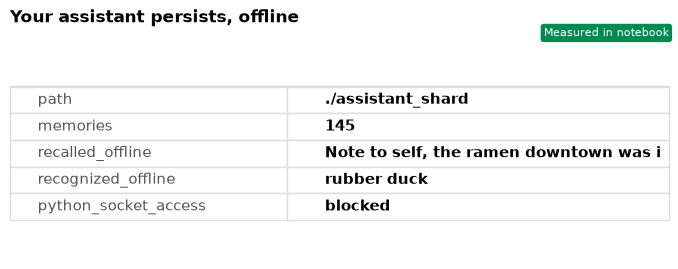

In [12]:
from helper import no_network, receipt_table

before = assistant_shard.info().points_count
assistant_shard.close()
with no_network():
    assistant_shard = EdgeShard.load(ASSISTANT_DIR)
    hits = recall(assistant_shard, "the ramen place downtown")
    top, known = recognize(assistant_shard, test_photo)

recalled = hits["Voice Notes"][0].payload["transcript"][:38]
recognized = top.payload["label"] if known else "UNKNOWN"

receipt_table([
    ("path", ASSISTANT_DIR),
    ("memories", before),
    ("recalled_offline", recalled),
    ("recognized_offline", recognized),
    ("python_socket_access", "blocked"),
], title="Your assistant persists, offline")